In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

from umap import UMAP
import trimap
import pacmap

%matplotlib inline

In [3]:
nb_classes = 10
dropout = 0.5

# Build very simple neural network with 2 hidden layers
model = Sequential([
    Input(shape=(784,)),
    Dense(256, activation="relu"),
    Dropout(dropout),
    Dense(64, activation="relu"),
    Dropout(dropout),
    Dense(nb_classes, activation="softmax")
])


model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [4]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Put everything on grayscale
X_train /= 255
X_test /= 255

# Convert class vectors to binary class matrices
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# Split training and validation data
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, train_size=5 / 6)

In [5]:
network_history = model.fit(
    X_train,
    Y_train,
    batch_size=128,
    epochs=20,
    verbose=1,
    validation_data=(X_val, Y_val),
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7999 - loss: 0.6504 - val_accuracy: 0.9373 - val_loss: 0.2107
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9126 - loss: 0.3087 - val_accuracy: 0.9565 - val_loss: 0.1540
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9327 - loss: 0.2453 - val_accuracy: 0.9613 - val_loss: 0.1298
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9425 - loss: 0.2062 - val_accuracy: 0.9652 - val_loss: 0.1180
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9488 - loss: 0.1834 - val_accuracy: 0.9686 - val_loss: 0.1054
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9538 - loss: 0.1655 - val_accuracy: 0.9710 - val_loss: 0.0975
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9560 - loss: 0.1569 - val_accuracy: 0.9704 - val_loss: 0.0949
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9594 - loss: 0.1427 - val_accuracy: 0.

In [6]:
def plot_history(network_history):
    plt.figure()
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(network_history.history['loss'])
    plt.plot(network_history.history['val_loss'])
    plt.legend(['Training', 'Validation'])

    plt.figure()
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.plot(network_history.history['accuracy'])
    plt.plot(network_history.history['val_accuracy'])
    plt.legend(['Training', 'Validation'], loc='lower right')
    plt.show()

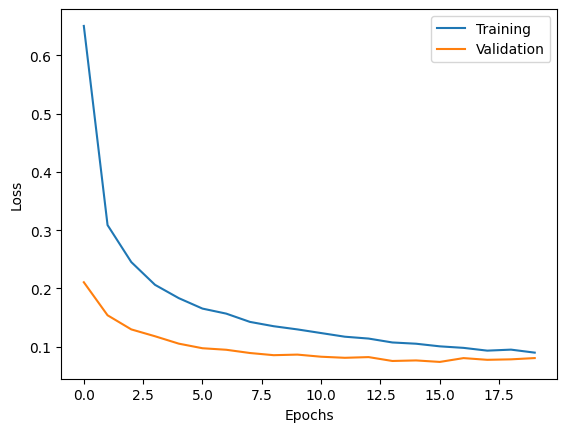

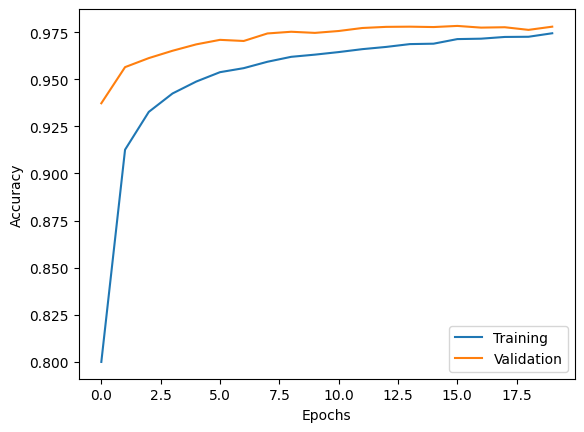

In [7]:
plot_history(network_history)

In [8]:
# Co ciekawe, na zbiorze walidacyjnym, mamy mniejszy błąd funkcji kosztu oraz większą dokładność. Prawdopodobnie, wynika to z zastosowania Dropoutu podczas treningu sieci, który jest już nieobecny przy walidacji, predykcji.
# Dropout to technika regualaryzacji, 50% neuronów nie działa, sieć działa w ograniczonym zakresie.

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654,176 (2.50 MB)

 Trainable params: 218,058 (851.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 436,118 (1.66 MB)

## Layer extractor

Wyodrębniam wyjścia warstw `Dense` z wytrenowanej sieci. Sequential w Keras 3 nie udostępnia bezpośrednio `.input` i `.output`, więc budujemy nowy functional model przepuszczając `Input` przez te same (już wytrenowane) warstwy.

In [10]:
inp = Input(shape=(784,))
x = inp
intermediate = []
for layer in model.layers:
    x = layer(x)
    if isinstance(layer, Dense):
        intermediate.append(x)

layer_outputs_model = Model(inputs=inp, outputs=intermediate)
print(f"Outputs captured: {len(intermediate)}")

Outputs captured: 3


## Podpróbka i aktywacje

Dla t-SNE/TriMAP/PaCMAP/UMAP używam podpróbki 5000 próbek treningowych i 2000 testowych — pełny zbiór jest zbyt duży (t-SNE jest O(n²)). Z `layer_outputs_model` pobieram aktywacje pierwszej (256) i drugiej (64) warstwy ukrytej.

In [11]:
N_TRAIN = 5000
N_TEST = 2000
rng = np.random.default_rng(42)

y_train_int = np.argmax(Y_train, axis=1)
y_test_int = np.argmax(Y_test, axis=1)

idx_train = rng.choice(len(X_train), N_TRAIN, replace=False)
idx_test = rng.choice(len(X_test), N_TEST, replace=False)

X_tr, y_tr = X_train[idx_train], y_train_int[idx_train]
X_te, y_te = X_test[idx_test], y_test_int[idx_test]

h1_tr, h2_tr, _ = layer_outputs_model(X_tr, training=False)
h1_te, h2_te, _ = layer_outputs_model(X_te, training=False)

h1_tr, h2_tr = h1_tr.numpy(), h2_tr.numpy()
h1_te, h2_te = h1_te.numpy(), h2_te.numpy()

print(f"Train: X={X_tr.shape}, h1={h1_tr.shape}, h2={h2_tr.shape}")
print(f"Test : X={X_te.shape}, h1={h1_te.shape}, h2={h2_te.shape}")

Train: X=(5000, 784), h1=(5000, 256), h2=(5000, 64)
Test : X=(2000, 784), h1=(2000, 256), h2=(2000, 64)


## Pomocnicze funkcje wizualizacji

In [12]:
PAL = np.array(sns.color_palette("tab10", 10))

def scatter_emb(ax, emb, labels, title):
    for c in range(10):
        mask = labels == c
        ax.scatter(emb[mask, 0], emb[mask, 1], s=1.5, alpha=0.55, color=PAL[c])
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])


def add_legend(fig, ncol=10):
    patches = [mpl.patches.Patch(color=PAL[i], label=str(i)) for i in range(10)]
    fig.legend(
        handles=patches,
        loc="lower center",
        ncol=ncol,
        fontsize=8,
        bbox_to_anchor=(0.5, -0.02),
    )

## Krok 1-2: Redukcja wymiarowości danych treningowych

Stosuję cztery metody (t-SNE, UMAP, TriMAP, PaCMAP) do trzech wejść: surowych pikseli, aktywacji pierwszej warstwy ukrytej i aktywacji drugiej warstwy ukrytej. Modele UMAP zachowuję, żeby później rzutować nimi dane testowe.

In [13]:
inputs_tr = {"raw": X_tr, "h1": h1_tr, "h2": h2_tr}
sources = ["raw", "h1", "h2"]
methods = ["t-SNE", "UMAP", "TriMAP", "PaCMAP"]

embeddings_tr = {}
umap_models = {}

for src, data in inputs_tr.items():
    print(f"--- {src} ---")

    embeddings_tr[(src, "t-SNE")] = TSNE(n_components=2, random_state=42).fit_transform(data)
    print("  t-SNE done")

    umap_m = UMAP(n_components=2, random_state=42)
    embeddings_tr[(src, "UMAP")] = umap_m.fit_transform(data)
    umap_models[src] = umap_m
    print("  UMAP done")

    embeddings_tr[(src, "TriMAP")] = trimap.TRIMAP().fit_transform(data)
    print("  TriMAP done")

    embeddings_tr[(src, "PaCMAP")] = pacmap.PaCMAP(n_components=2).fit_transform(data)
    print("  PaCMAP done")

--- raw ---
  t-SNE done


C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP done
  TriMAP done
  PaCMAP done
--- h1 ---
  t-SNE done


C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP done
  TriMAP done
  PaCMAP done
--- h2 ---
  t-SNE done


C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP done
  TriMAP done
  PaCMAP done


## Krok 3: Wizualizacja embeddingów - dane treningowe

Siatka 3×4: wiersze to źródło wejścia (surowe piksele, hidden 1, hidden 2), kolumny to metoda redukcji.

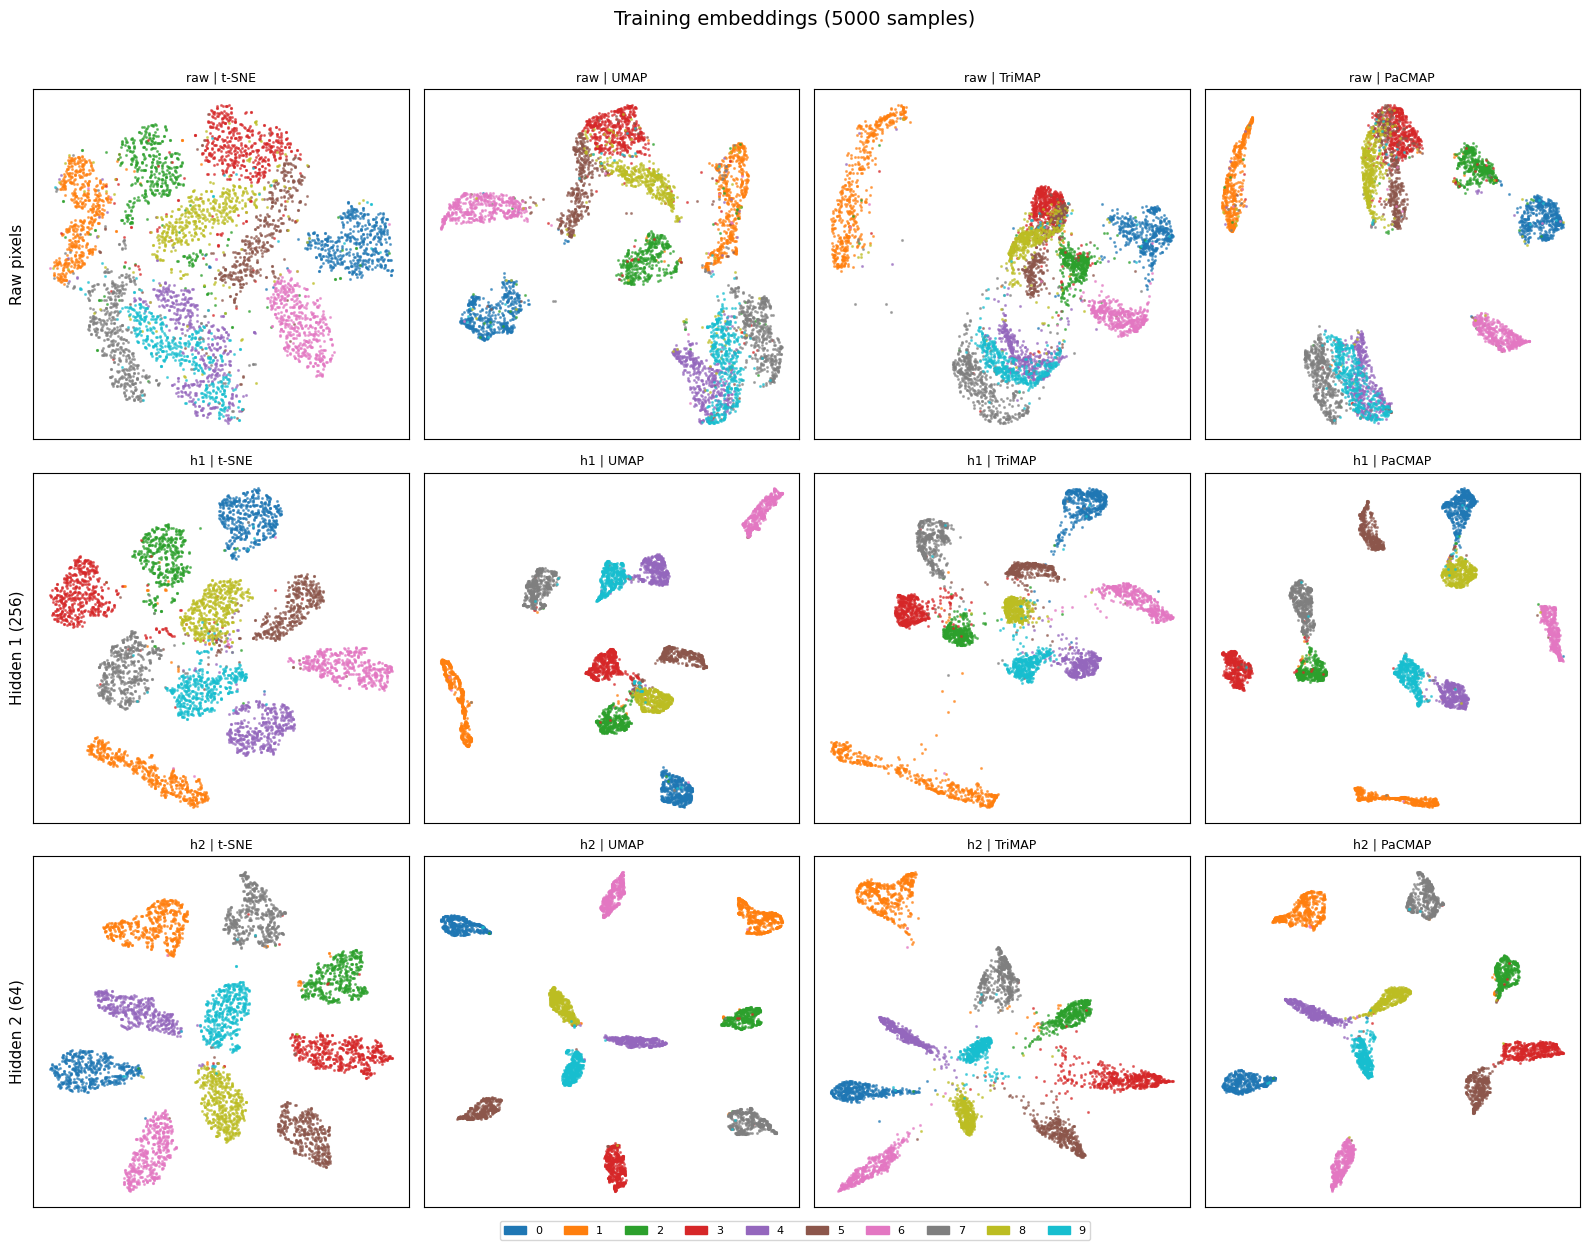

In [14]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

row_labels = {"raw": "Raw pixels", "h1": "Hidden 1 (256)", "h2": "Hidden 2 (64)"}

for r, src in enumerate(sources):
    for c, m in enumerate(methods):
        scatter_emb(axes[r, c], embeddings_tr[(src, m)], y_tr, f"{src} | {m}")
    axes[r, 0].set_ylabel(row_labels[src], fontsize=11, labelpad=6)

fig.suptitle("Training embeddings (5000 samples)", fontsize=14, y=1.01)
add_legend(fig)
plt.tight_layout()
plt.show()

## Krok 4: Projekcja danych testowych (UMAP)

t-SNE, TriMAP i PaCMAP są nieparametryczne — nie da się nimi rzutować nowych punktów na istniejący manifold. UMAP ma metodę `transform`, więc używamy go do projekcji danych testowych. Modele UMAP zostały już dopasowane w poprzednim kroku (po jednym dla każdego źródła).

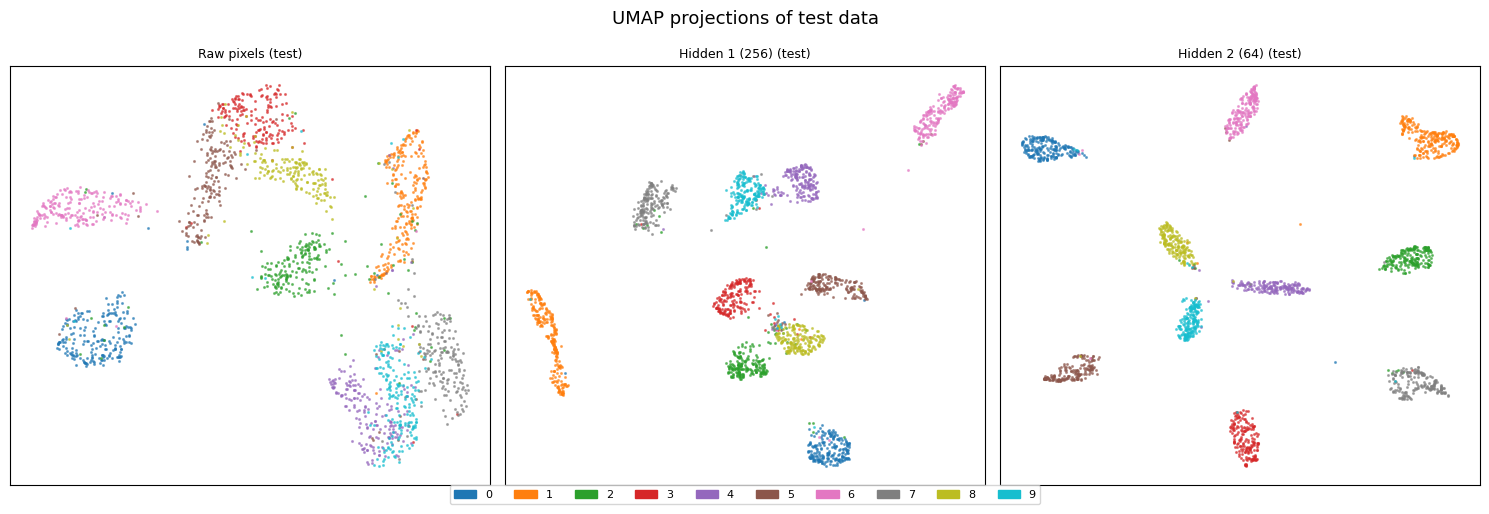

In [15]:
inputs_te = {"raw": X_te, "h1": h1_te, "h2": h2_te}
embeddings_te_umap = {
    src: umap_models[src].transform(inputs_te[src]) for src in sources
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for c, src in enumerate(sources):
    scatter_emb(axes[c], embeddings_te_umap[src], y_te, f"{row_labels[src]} (test)")
fig.suptitle("UMAP projections of test data", fontsize=13)
add_legend(fig)
plt.tight_layout()
plt.show()

## Krok 5: Klasyfikacja kNN na embeddingach UMAP

Dla każdego źródła (raw / h1 / h2) trenuję kNN na 2D-embeddingach UMAP zbioru treningowego, a klasyfikuję 2D-projekcje zbioru testowego. Sprawdzam `n_neighbors` ∈ {3, 5, 10}.

In [16]:
n_neighbors_list = [3, 5, 10]
records = []

for src in sources:
    X_emb_tr = embeddings_tr[(src, "UMAP")]
    X_emb_te = embeddings_te_umap[src]
    for k in n_neighbors_list:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_emb_tr, y_tr)
        acc = accuracy_score(y_te, knn.predict(X_emb_te))
        records.append({"input": src, "n_neighbors": k, "accuracy": round(acc, 4)})
        print(f"  {src:<4}  n_neighbors={k:>2}   accuracy={acc:.4f}")

df_results = pd.DataFrame(records)

  raw   n_neighbors= 3   accuracy=0.8780
  raw   n_neighbors= 5   accuracy=0.8870
  raw   n_neighbors=10   accuracy=0.8910
  h1    n_neighbors= 3   accuracy=0.9495
  h1    n_neighbors= 5   accuracy=0.9560
  h1    n_neighbors=10   accuracy=0.9565
  h2    n_neighbors= 3   accuracy=0.9770
  h2    n_neighbors= 5   accuracy=0.9780
  h2    n_neighbors=10   accuracy=0.9780


In [17]:
pivot = df_results.pivot(index="input", columns="n_neighbors", values="accuracy")
pivot = pivot.reindex(sources)
pivot.style.format("{:.4f}").background_gradient(cmap="RdYlGn", axis=None)

n_neighbors,3,5,10
input,,,
raw,0.8780,0.8870,0.8910
h1,0.9495,0.9560,0.9565
h2,0.9770,0.9780,0.9780


## Wnioski

Spodziewamy się, że accuracy rośnie wraz z głębokością źródła: surowe piksele dają najmniej separowalną geometrię, hidden 1 już wydobywa cechy, hidden 2 jest najbardziej "konceptualne". Wartość `n_neighbors` ma mniejszy wpływ przy dobrze rozdzielonych klastrach.

Wynik to nie ocena samego klasyfikatora — jest to ocena **jakości embeddingu 2D** dla potrzeb klasyfikacji. Sieć neuronowa pełni rolę nieliniowej transformacji, która przesuwa dane w taki sposób, że kolejne metody redukcji wymiarowości łatwiej oddzielają klasy.